# A CLSM flow phantom: recover a spatially varying velocity field

A raster scan of a diffusing sample carries a diffusion coefficient — that is RICS. If the
sample also **flows**, the same scan carries the velocity, and because the flow can differ
from place to place, one scan can carry a whole velocity **map**.

This builds a phantom whose answer is obvious by construction: three horizontal bands,
each with its own known velocity along $x$.

```
    top     v = +6 um/s   ------->
    middle  v =  0
    bottom  v = -6 um/s   <-------
```

Same diffusion coefficient everywhere. Analysing each band on its own must return the
velocity that band was given — **including the sign**, which is the part a correlation
analysis can get backwards without anyone noticing.

Three design choices are deliberate:

* **The bands run along the flow.** A molecule then stays in its own band for ever rather
  than being swept into the next, so each band really is a separate experiment.
* **Each band crop is wider than it is tall.** Image correlation runs on a cropped region
  and the crop shape used to matter; keeping it wide costs nothing here.
* **Velocities are in µm/s and used as-is.** This scan sets `dt` to the pixel dwell in
  *seconds* and `D` in µm²/s, so the simulator's macro-time unit **is** the second.
  Converting again scales the field down by ~1e-5 and the flow silently vanishes — every
  call still succeeds and the only symptom is a correlation peak that never leaves zero lag.

The companion script is `flow_02_clsm_stics_phantom.py`; the simulator itself is introduced
in [flow_01_advection_diffusion.ipynb](flow_01_advection_diffusion.ipynb).

In [1]:
from pathlib import Path

import matplotlib
import numpy as np

matplotlib.use("Agg")
import matplotlib.pyplot as plt

import tttrlib

plt.rcParams["figure.dpi"] = 110
# Works as a script and as a notebook cell (a notebook has no __file__).
try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path.cwd()
FIGURES = _HERE / "figures"
FIGURES.mkdir(exist_ok=True)

# --- the phantom ---------------------------------------------------------------------
N_PIX = 96             # pixels per line (square field)
PIXEL = 0.1            # um
PIXEL_TIME = 4.0e-6    # s
N_FRAMES = 300
D_TRUE = 0.1           # um^2/s
V_TRUE = 6.0           # um/s in the outer bands, opposite signs
W_R, W_Z = 0.25, 1.0   # focus waists, um
N_MOL = 600.0
BRIGHTNESS = 4.0e6     # photons/s at the focus centre
SEED = 7

FIELD = N_PIX * PIXEL                       # 9.6 um across
BAND = N_PIX // 3                           # 32 rows per band
FRAME_TIME = N_PIX * N_PIX * PIXEL_TIME     # s
BAND_V = (-V_TRUE, 0.0, +V_TRUE)            # bottom, middle, top
BAND_NAME = ("bottom", "middle", "top")
BOX_XY = 0.5 * FIELD * np.sqrt(2.0) + 4.0 * W_R
BOX_Z = 4.0
EDGES = (-FIELD / 2 + BAND * PIXEL, -FIELD / 2 + 2 * BAND * PIXEL)
EXTENT = [-FIELD / 2, FIELD / 2, -FIELD / 2, FIELD / 2]

print(f"field {FIELD:.1f} x {FIELD:.1f} um, frame time {FRAME_TIME * 1e3:.1f} ms")
print(f"flow displacement per frame : {V_TRUE * FRAME_TIME / PIXEL:.2f} px")
print(f"diffusion per frame         : {np.sqrt(4 * D_TRUE * FRAME_TIME) / PIXEL:.2f} px")

field 9.6 x 9.6 um, frame time 36.9 ms
flow displacement per frame : 2.21 px
diffusion per frame         : 1.21 px


Those last two numbers decide whether this works at all. For the flow to be visible between
frames it must move the sample **further than diffusion smears it**: $v\,t_{frame}$ against
$\sqrt{4Dt_{frame}}$, here 2.2 px against 1.2 px. Raise $D$ or shorten the frame and the
velocity becomes unrecoverable however long you acquire.

## 1. The vector field

Built on a lattice with `SimVectorGrid.from_numpy` rather than an analytic builder, because
the point of a phantom is that it is **blocky**: each band holds one velocity, so what a
per-band analysis should return is not a matter of interpretation. The lattice must cover
the whole simulation box — a `SimGrid` samples to zero outside itself, so flow would
otherwise stop at its edge.

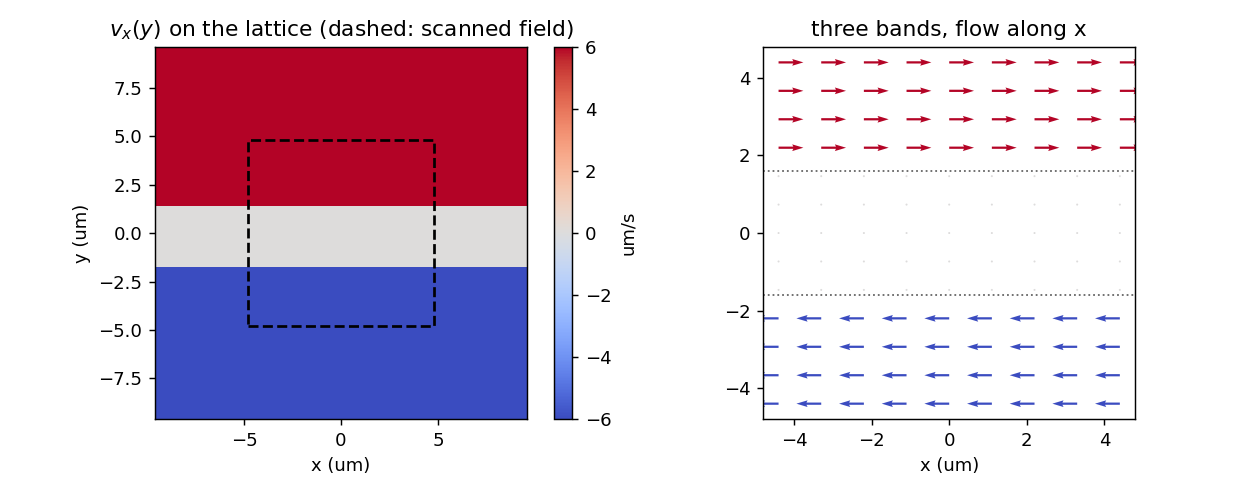

In [2]:
def banded_flow():
    """A piecewise-constant v_x(y): -V, 0, +V across the scanned field.

    Built on a lattice with `from_numpy` rather than one of the analytic builders,
    because the point of a phantom is that it is BLOCKY: each band holds one velocity, so
    what a per-band analysis should return is not a matter of interpretation.

    The lattice has to cover the whole simulation box, not just the scanned field -- a
    SimGrid samples to zero outside itself, so flow would otherwise stop at its edge.
    """
    half = FIELD
    n = 49
    step = 2 * half / (n - 1)
    ys = -half + np.arange(n) * step
    vx = np.zeros((n, n, n))                # (nz, ny, nx)
    for iy, y in enumerate(ys):
        vx[:, iy, :] = (BAND_V[0] if y < EDGES[0]
                        else BAND_V[1] if y < EDGES[1] else BAND_V[2])
    zeros = np.zeros_like(vx)
    return tttrlib.SimVectorGrid.from_numpy(vx, zeros, zeros, dx=step, dy=step, dz=step)


def plot_field():
    n = 49
    step = 2 * FIELD / (n - 1)
    ys = -FIELD + np.arange(n) * step
    vx_map = np.where(ys < EDGES[0], BAND_V[0], np.where(ys < EDGES[1], BAND_V[1], BAND_V[2]))

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
    im = axes[0].imshow(np.tile(vx_map[:, None], (1, n)), origin="lower",
                        extent=[-FIELD, FIELD, -FIELD, FIELD], cmap="coolwarm",
                        vmin=-V_TRUE, vmax=V_TRUE, aspect="equal")
    axes[0].add_patch(plt.Rectangle((-FIELD / 2, -FIELD / 2), FIELD, FIELD,
                                    fill=False, ec="k", lw=1.5, ls="--"))
    axes[0].set_title(r"$v_x(y)$ on the lattice (dashed: scanned field)")
    axes[0].set_xlabel("x (um)"); axes[0].set_ylabel("y (um)")
    fig.colorbar(im, ax=axes[0], label="um/s")

    yq = np.linspace(-FIELD / 2 + 0.4, FIELD / 2 - 0.4, 13)
    xq = np.linspace(-FIELD / 2 + 0.4, FIELD / 2 - 0.4, 9)
    XQ, YQ = np.meshgrid(xq, yq)
    VQ = np.where(YQ < EDGES[0], BAND_V[0], np.where(YQ < EDGES[1], BAND_V[1], BAND_V[2]))
    axes[1].quiver(XQ, YQ, VQ, np.zeros_like(VQ), VQ, cmap="coolwarm",
                   clim=(-V_TRUE, V_TRUE), scale=90, width=0.006)
    for e in EDGES:
        axes[1].axhline(e, color="0.4", lw=1, ls=":")
    axes[1].set_xlim(-FIELD / 2, FIELD / 2); axes[1].set_ylim(-FIELD / 2, FIELD / 2)
    axes[1].set_aspect("equal")
    axes[1].set_title("three bands, flow along x"); axes[1].set_xlabel("x (um)")
    fig.tight_layout()
    fig.savefig(FIGURES / "flow_02_field.png", dpi=130)
    plt.close(fig)

plot_field()
from IPython.display import Image
Image(str(FIGURES / 'flow_02_field.png'))

## 2. Simulate the scan

Photon by photon through a moving Gaussian focus. Molecules are injected across the box
surface so the concentration stays stationary, and the advection-aware surface flux keeps
it stationary *under flow* too — without that the box drains downstream while everything
still looks plausible.

Note `sample.set_flow_field(...)` happens **before** the engine is constructed: `SimEngine`
takes the `SimSystem` by value, so anything set afterwards lands on a copy it never sees.

(300, 96, 96) frames, 3104579 photons, 1.12 counts/pixel


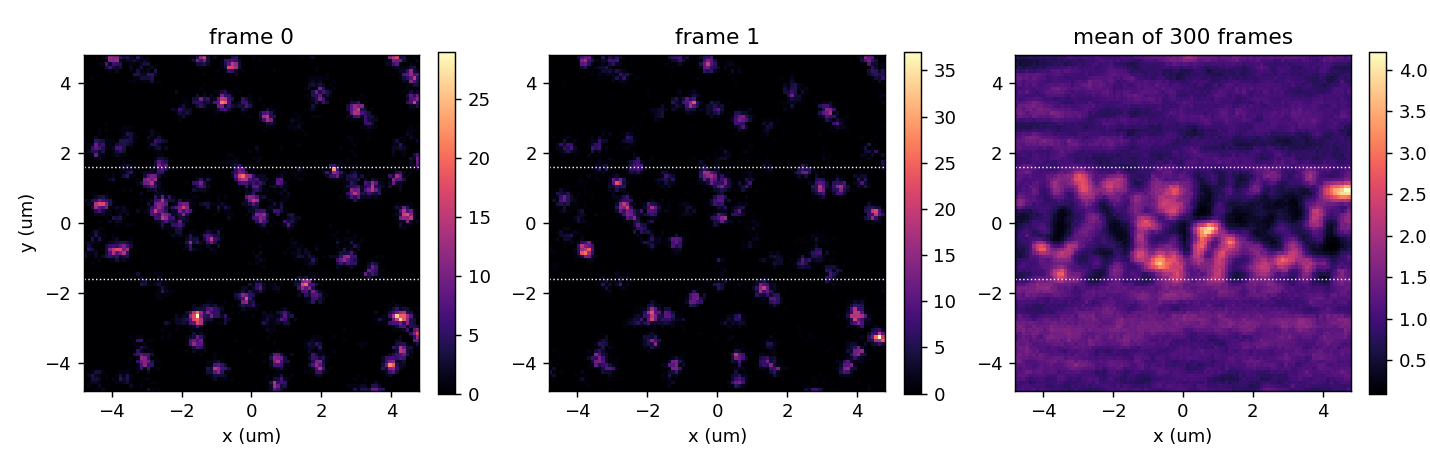

In [3]:
def simulate_scan(flow_field):
    """Raster-scan a flowing, diffusing population and bin the photons into images."""
    sample = tttrlib.SimSystem()
    species = tttrlib.SimSpecies()
    species.D = D_TRUE
    species.q = [BRIGHTNESS]
    sample.add_species(species)
    sample.set_rate_matrices([0.0], [0.0])
    sample.set_background([0.0])
    sample.set_box(BOX_XY, BOX_Z)
    sample.set_population(0, N_MOL)
    # BEFORE constructing the engine: SimEngine takes the SimSystem by value, so anything
    # set afterwards lands on a copy the engine never sees.
    sample.set_flow_field(flow_field)

    settings = tttrlib.SimIntegrator()
    settings.dt = PIXEL_TIME               # macro-time unit is the second here
    settings.n_channels = 1
    settings.n_ph_max = 10 ** 12
    settings.seed_diffusion = SEED
    settings.seed_emission = SEED + 1
    settings.fast_grid_bbox = True
    # Coasting must stay OFF for a scan: it skips molecules far from the focus, but the
    # beam moves TO them, so those are exactly the ones about to be scanned.

    excitation = tttrlib.SimGrid.gaussian3d(
        W_R, W_Z, 4.0 * W_R, min(4.0 * W_Z, BOX_Z), 0.05, 1.0)
    engine = tttrlib.SimEngine(sample, excitation, [], settings)

    scanner = tttrlib.SimScanner.uniform(
        N_PIX, N_PIX, PIXEL_TIME, PIXEL, PIXEL,
        -0.5 * FIELD, -0.5 * FIELD, tttrlib.SimMarkerConfig(), False)
    for _ in range(N_FRAMES):
        engine.run_scan(scanner)

    # Markers outnumber photons in a scan (one per pixel, plus line and frame markers),
    # so the raw record stream must be filtered: event type 0 is a photon.
    event_type = np.asarray(engine.event_type())
    windows = np.asarray(engine.macro_window(), dtype=np.int64)[event_type == 0]
    total = N_PIX * N_PIX * N_FRAMES
    windows = windows[(windows >= 0) & (windows < total)]
    counts = np.bincount(windows, minlength=total)
    return counts.astype(float).reshape(N_FRAMES, N_PIX, N_PIX), int(windows.size)


def plot_images(images):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
    panels = [("frame 0", images[0]), ("frame 1", images[1]),
              (f"mean of {N_FRAMES} frames", images.mean(axis=0))]
    for ax, (title, img) in zip(axes, panels):
        m = ax.imshow(img, origin="lower", cmap="magma", extent=EXTENT)
        ax.set_title(title); ax.set_xlabel("x (um)")
        for e in EDGES:
            ax.axhline(e, color="w", lw=0.8, ls=":")
        fig.colorbar(m, ax=ax, fraction=0.046)
    axes[0].set_ylabel("y (um)")
    fig.tight_layout()
    fig.savefig(FIGURES / "flow_02_images.png", dpi=130)
    plt.close(fig)

images, n_photons = simulate_scan(banded_flow())
print(f'{images.shape} frames, {n_photons} photons, {images.mean():.2f} counts/pixel')
plot_images(images)
Image(str(FIGURES / 'flow_02_images.png'))

A single frame is mostly shot noise at ~1 count per pixel — the flow is nowhere visible by
eye, and the time average is flat because the sample is statistically stationary.
Everything below comes out of the **correlations**.

## 3. Correlation, band by band

`compute_ics` returns the spatial correlation for each frame pair; averaging the pairs at a
given frame lag $\Delta$ and centring the zero lag gives the map. RICS reads $\Delta = 0$;
STICS reads $\Delta > 0$, where a flowing sample moves the peak by $v\,\Delta\,t_{frame}$.

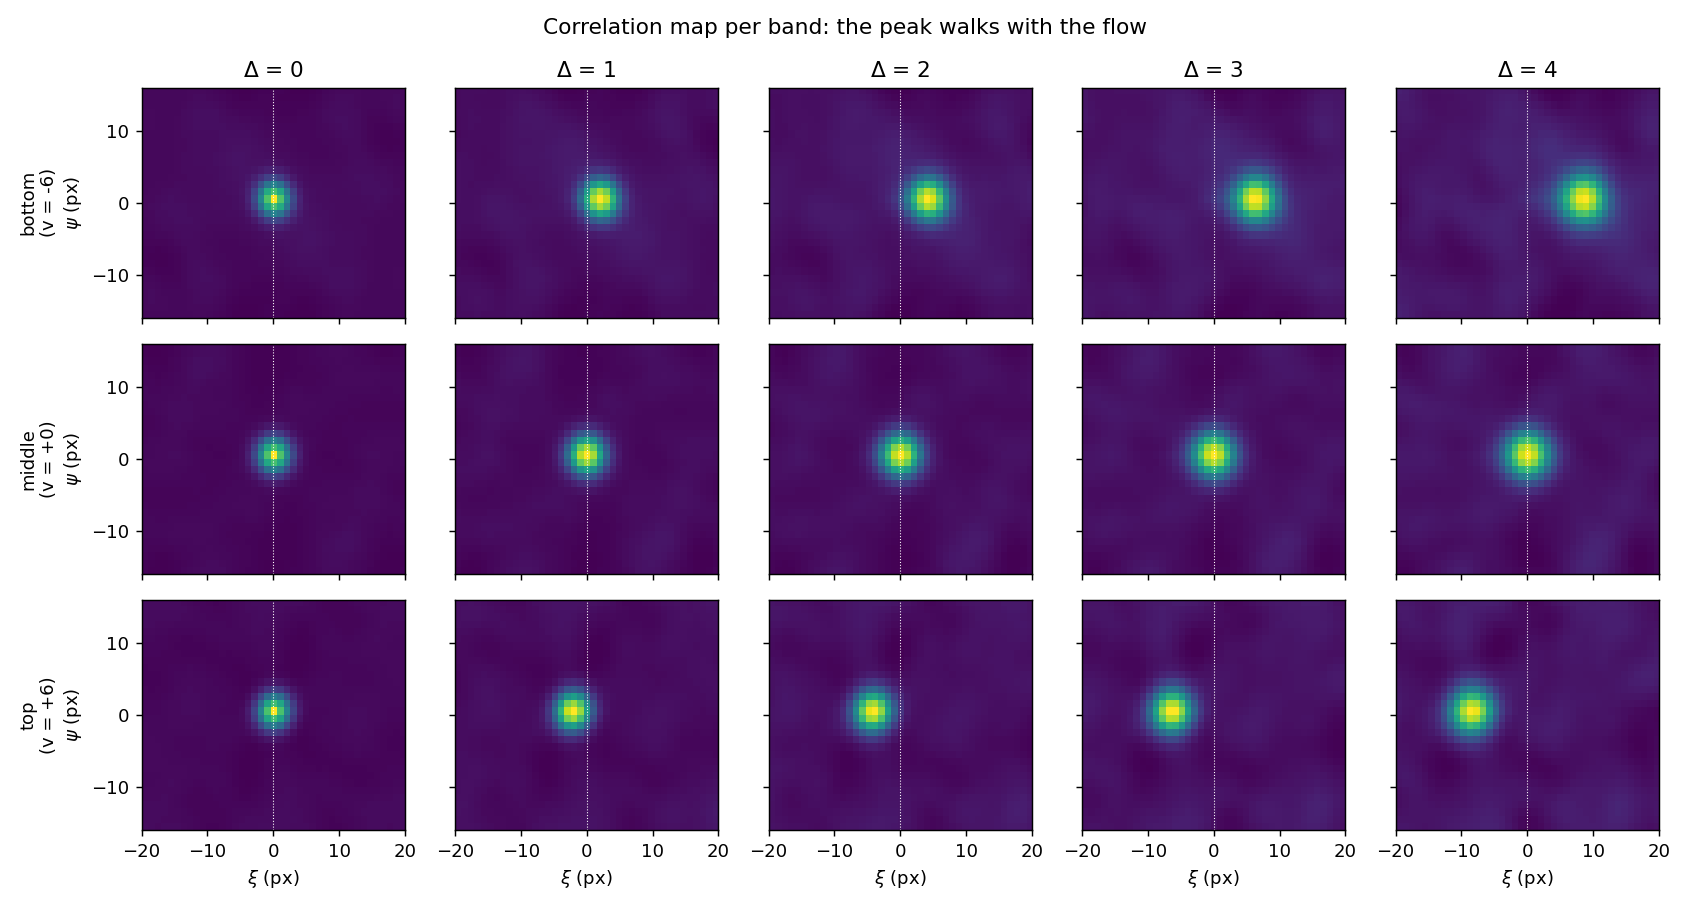

In [4]:
LAGS = [0, 1, 2, 3, 4]


def band_maps(images, k):
    """Averaged spatial correlation map per frame lag, for one band. Zero lag centred."""
    sub = np.ascontiguousarray(images[:, k * BAND:(k + 1) * BAND, :])
    out = []
    for lag in LAGS:
        pairs = [(i, i + lag) for i in range(sub.shape[0] - lag)]
        raw = np.asarray(tttrlib.CLSMImage.compute_ics(
            images=sub, x_range=[0, -1], y_range=[0, -1],
            subtract_average="frame", frames_index_pairs=pairs))
        m = raw[:len(pairs)].mean(axis=0)
        # Normalise as PAM and the STICS references do: G = corr / (N * <I>^2) - 1.
        m = m / (m.size * sub.mean() ** 2) - 1.0
        out.append(np.fft.fftshift(m))
    return np.asarray(out)


def plot_carpets(maps_per_band):
    fig, axes = plt.subplots(3, len(LAGS), figsize=(13, 7), sharex=True, sharey=True)
    for k in range(3):
        m = maps_per_band[k]
        cy, cx = m.shape[1] // 2, m.shape[2] // 2
        for i, lag in enumerate(LAGS):
            ax = axes[k, i]
            ax.imshow(m[i][:, cx - 20:cx + 21], origin="lower", cmap="viridis",
                      extent=[-20, 20, -cy, m.shape[1] - cy], aspect="auto")
            ax.axvline(0, color="w", lw=0.6, ls=":")
            if k == 0:
                ax.set_title(rf"$\Delta$ = {lag}")
            if i == 0:
                ax.set_ylabel(f"{BAND_NAME[k]}\n(v = {BAND_V[k]:+.0f})\n$\\psi$ (px)")
            if k == 2:
                ax.set_xlabel(r"$\xi$ (px)")
    fig.suptitle("Correlation map per band: the peak walks with the flow")
    fig.tight_layout()
    fig.savefig(FIGURES / "flow_02_carpets.png", dpi=130)
    plt.close(fig)

maps_per_band = [band_maps(images, k) for k in range(3)]
plot_carpets(maps_per_band)
Image(str(FIGURES / 'flow_02_carpets.png'))

The middle band's peak stays put; the outer bands walk in opposite directions. That is the
whole phantom in one picture.

## 4. Recover the velocity

Track the peak along the fast axis at each lag and fit a line: the slope is a displacement
per frame, so dividing by the frame time gives a velocity.

**The sign.** With this conjugation order — frame $i$ against frame $i+\Delta$ — the peak
moves *opposite* to the flow, so recovering $v$ needs a minus sign. The phantom pins that
down by construction: the outer bands carry opposite velocities, so a sign error cannot hide.

band       v true   v found       G(0)
bottom      -6.00     -5.89      5.475
middle       0.00      0.03      5.321
top          6.00      5.90      6.223


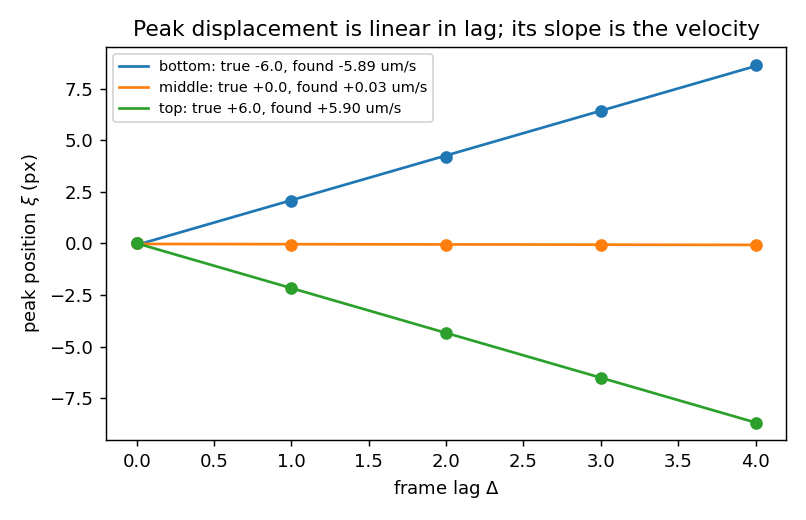

In [5]:
def peak_shift(m):
    """Sub-pixel peak position along the fast axis, in pixels from zero lag."""
    cy, cx = m.shape[0] // 2, m.shape[1] // 2
    row = m[cy]
    ix = int(np.argmax(row))
    if 0 < ix < row.size - 1:                       # parabolic refinement
        a, b, c = row[ix - 1], row[ix], row[ix + 1]
        denom = a - 2 * b + c
        ix = ix + (0.5 * (a - c) / denom if denom != 0 else 0.0)
    return ix - cx


def recover(maps_per_band):
    """Fit peak displacement against frame lag; the slope is the velocity."""
    lags = np.asarray(LAGS, dtype=float)
    fig, ax = plt.subplots(figsize=(6.2, 4))
    found = []
    for k in range(3):
        shifts = np.array([peak_shift(maps_per_band[k][i]) for i in range(len(LAGS))])
        slope, intercept = np.polyfit(lags, shifts, 1)
        # With this conjugation order -- frame i against frame i+lag -- the peak moves
        # OPPOSITE to the flow, hence the minus sign. The phantom pins that down: the
        # outer bands carry opposite velocities, so a sign error cannot hide.
        v = -slope * PIXEL / FRAME_TIME
        found.append(v)
        ax.plot(lags, shifts, "o", color=f"C{k}")
        ax.plot(lags, slope * lags + intercept, "-", color=f"C{k}",
                label=f"{BAND_NAME[k]}: true {BAND_V[k]:+.1f}, found {v:+.2f} um/s")
    ax.set_xlabel(r"frame lag $\Delta$"); ax.set_ylabel(r"peak position $\xi$ (px)")
    ax.set_title("Peak displacement is linear in lag; its slope is the velocity")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / "flow_02_recovery.png", dpi=130)
    plt.close(fig)
    return found

found = recover(maps_per_band)
print(f"{'band':<8}{'v true':>9}{'v found':>10}{'G(0)':>11}")
for k in range(3):
    print(f'{BAND_NAME[k]:<8}{BAND_V[k]:>9.2f}{found[k]:>10.2f}{maps_per_band[k][0].max():>11.3f}')
Image(str(FIGURES / 'flow_02_recovery.png'))

## 5. Movies, for inspection

Numbers are not the only check. A movie shows directly whether molecules move the way they
were told to — and it is the fastest way to notice that a flow field is not being applied
at all.

Three short clips. Two are the **same data**: the raw frames, which are what a scan of a
dilute sample really looks like (~1 count per pixel, pure shot noise, no visible
structure), and a 15-frame sliding average, which is enough to see the sample. The
averaging is only for the eye — the correlation analysis above uses the raw frames.

The third is a separate run with a handful of *bright* molecules, where each one is a
visible spot that walks left, stays put, or walks right depending on its band. That is the
one to look at when checking a flow field.

raw 40, averaged 40, molecules 50 frames


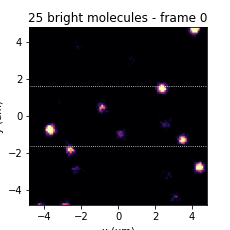

In [6]:
def save_movie(images, path, fps=12, smooth=1, title="", vmax_pct=99.5,
               stride=1, limit=None, size=3.2, dpi=72):
    """Write an animated GIF of an image stack.

    A raster scan at ~1 count per pixel is pure shot noise frame by frame, and the flow is
    invisible in it. `smooth` averages a sliding window of frames before writing, which is
    what makes motion visible without changing the data the analysis sees.
    """
    from matplotlib.animation import FuncAnimation, PillowWriter

    stack = images
    if smooth > 1:
        kernel = np.ones(smooth) / smooth
        stack = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="valid"),
                                    0, images)
    stack = stack[::stride]
    if limit is not None:
        stack = stack[:limit]
    # These are committed to the repository, so keep them small: a 286-frame GIF at full
    # figure size is 10 MB, which is not a thing to put in git.
    vmax = np.percentile(stack, vmax_pct)
    fig, ax = plt.subplots(figsize=(size, size), dpi=dpi)
    im = ax.imshow(stack[0], origin="lower", cmap="magma", extent=EXTENT,
                   vmin=0.0, vmax=vmax)
    for e in EDGES:
        ax.axhline(e, color="w", lw=0.8, ls=":")
    ax.set_xlabel("x (um)"); ax.set_ylabel("y (um)")
    txt = ax.set_title(f"{title} frame 0")

    def update(k):
        im.set_data(stack[k])
        txt.set_text(f"{title} frame {k}")
        return im, txt

    anim = FuncAnimation(fig, update, frames=len(stack), blit=False)
    anim.save(path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return len(stack)


def sparse_demo_stack():
    """A few bright molecules, so the drift is visible to the eye.

    The phantom itself is deliberately dilute -- that is the FCS regime the correlation
    analysis needs. For *looking* at the flow, a handful of bright molecules is far more
    informative: each one is a visible spot that walks left, stays put, or walks right
    depending on which band it is in.
    """
    saved = (globals()["N_MOL"], globals()["BRIGHTNESS"], globals()["N_FRAMES"])
    globals()["N_MOL"], globals()["BRIGHTNESS"], globals()["N_FRAMES"] = 25.0, 2.0e7, 120
    try:
        images, _ = simulate_scan(banded_flow())
    finally:
        globals()["N_MOL"], globals()["BRIGHTNESS"], globals()["N_FRAMES"] = saved
    return images

n_raw = save_movie(images, FIGURES / 'flow_02_phantom_raw.gif', smooth=1, stride=1,
                   limit=40, title='raw frames -')
n_avg = save_movie(images, FIGURES / 'flow_02_phantom_avg.gif', smooth=15, stride=4,
                   limit=40, title='15-frame average -')
demo = sparse_demo_stack()
n_mol = save_movie(demo, FIGURES / 'flow_02_molecules.gif', smooth=1, stride=2,
                   limit=50, fps=10, title='25 bright molecules -')
print(f'raw {n_raw}, averaged {n_avg}, molecules {n_mol} frames')
Image(str(FIGURES / 'flow_02_molecules.gif'))

Each band returns the velocity it was given, sign included, from a scan in which the flow is
invisible to the eye.

## What this phantom is for

Ground truth for anything claiming to measure transport from an image series — STICS, iMSD,
and pair-correlation (pCF) analysis, where the correlation between two points a distance
$\delta$ apart peaks at the time molecules need to travel $\delta$. Because the field is
blocky and the bands are independent, a method that is subtly wrong has nowhere to hide: it
must reproduce three different answers from one dataset, two differing only in sign.

Extending it is mostly a matter of changing `banded_flow`: a Poiseuille profile tests a
*continuously* varying velocity, and an occlusion mask tests whether a method can see a
barrier at all — the case where a pair correlation should collapse while both local
autocorrelations stay put.